# Pragma injection audit

Post-graph inspection of injected Vitis pragmas. This notebook reads existing graph JSON files only. It does not compile, regraph, tensorize datasets, or modify artifacts.

It answers four questions: what was injected, which arguments are retained versus encoded by the current tensor schema, how pragmas are anchored, and which attachments need manual review.

In [1]:
from collections import Counter, defaultdict
import json
import math
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import clear_output, display

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

cwd = Path.cwd().resolve()
REPO_ROOT = next(
    path for path in (cwd, cwd.parent, cwd / 'll-hls4ml')
    if (path / 'src' / 'll_hls4ml').is_dir()
)
sys.path.insert(0, str(REPO_ROOT / 'src'))

from ll_hls4ml.data.tensorize import pragma_embedding
from ll_hls4ml.io.schema import (
    FLOW_PRAGMA,
    NODE_PRAGMA,
    NODE_TYPES,
    PRAGMA_ARGUMENT_DIRECTIVES,
    PRAGMA_CATEGORICAL_ARGUMENTS,
    PRAGMA_NUMERIC_ARGUMENTS,
    PRAGMA_SCHEMA_VERSION,
    PRAGMA_TARGET_ARGUMENTS,
    PRAGMA_VOCAB,
)

GRAPH_ROOT = Path(os.environ.get(
    'LL_HLS4ML_GRAPH_ROOT', REPO_ROOT.parent / 'data' / 'graphs'
)).resolve()

# Set either filter to a collection of names, or leave as None for everything.
KERNEL_FILTER = None       # e.g. {'2layer', 'conv1d'}
ARCHIVE_FILTER = None      # e.g. {'archive_1', 'archive_4'}
MAX_GRAPHS = None          # e.g. 100 for a quick sampled audit

print(f'Repository: {REPO_ROOT}')
print(f'Graph root: {GRAPH_ROOT}')

Repository: /home/brend/projects/ll-hls4ml
Graph root: /home/brend/projects/data/graphs


## Current learned schema

Every known pragma directive has a categorical ID. Only the directives listed below receive argument features. Numeric fields use a value plus a presence mask; categorical fields use explicit named slots. Target names are deliberately omitted from node features because `pragma → target` edges represent them structurally. Everything else remains losslessly available in graph JSON but is not consumed by the model.

In [2]:
display(pd.DataFrame({
    'directive': sorted(PRAGMA_VOCAB, key=PRAGMA_VOCAB.get),
    'directive_id': [PRAGMA_VOCAB[key] for key in sorted(PRAGMA_VOCAB, key=PRAGMA_VOCAB.get)],
    'arguments_encoded': [key in PRAGMA_ARGUMENT_DIRECTIVES for key in sorted(PRAGMA_VOCAB, key=PRAGMA_VOCAB.get)],
}))
display(pd.DataFrame({'numeric_argument': PRAGMA_NUMERIC_ARGUMENTS}))
display(pd.DataFrame(PRAGMA_CATEGORICAL_ARGUMENTS, columns=['argument', 'encoded_value']))

,directive,directive_id,arguments_encoded
0,UNK,0,False
1,pragma.allocation,1,True
2,pragma.array_partition,2,True
3,pragma.array_reshape,3,True
4,pragma.dataflow,4,True
5,pragma.function_instantiate,5,False
6,pragma.inline,6,True
7,pragma.interface,7,True
8,pragma.pipeline,8,True
9,pragma.unroll,9,True


,numeric_argument
0,ii
1,factor
2,dim
3,depth
4,min
5,max
6,avg
7,latency
8,interval
9,num


,argument,encoded_value
0,complete,true
1,block,true
2,cyclic,true
3,rewind,true
4,enable_flush,true
5,disable_start_propagation,true
6,off,true
7,recursive,true
8,skip_exit_check,true
9,force,true


In [3]:
def graph_paths(root=GRAPH_ROOT):
    paths = []
    for kernel_dir in sorted(root.iterdir() if root.is_dir() else []):
        if not kernel_dir.is_dir() or (KERNEL_FILTER and kernel_dir.name not in KERNEL_FILTER):
            continue
        for archive_dir in sorted(kernel_dir.glob('archive_*')):
            if ARCHIVE_FILTER and archive_dir.name not in ARCHIVE_FILTER:
                continue
            paths.extend(sorted(archive_dir.glob('*.json')))
    return paths[:MAX_GRAPHS] if MAX_GRAPHS else paths


def feature_value(node, key, default=''):
    value = node.get('features', {}).get(key, [default])
    return value[0] if isinstance(value, list) and value else value


def pragma_arguments(node):
    raw = feature_value(node, 'arguments_json', '{}')
    try:
        value = json.loads(raw)
    except (TypeError, json.JSONDecodeError):
        return {}
    return value if isinstance(value, dict) else {}


def full_text(node):
    value = node.get('features', {}).get('full_text', [])
    return '\n'.join(map(str, value)) if isinstance(value, list) else str(value)


def argument_coverage(node):
    directive = node.get('text', 'pragma.unknown')
    arguments = pragma_arguments(node)
    encoded, retained, structural = [], [], []
    if directive not in PRAGMA_ARGUMENT_DIRECTIVES:
        retained = [f'{key}={value}' for key, values in arguments.items() for value in values]
        return 'directive_only', encoded, retained, structural

    numeric = set(PRAGMA_NUMERIC_ARGUMENTS)
    categorical = set(PRAGMA_CATEGORICAL_ARGUMENTS)
    for key, values in arguments.items():
        for raw_value in values:
            value = str(raw_value)
            token = f'{key}={value}'
            if key in PRAGMA_TARGET_ARGUMENTS:
                structural.append(token)
                continue
            try:
                number = float(value)
                is_number = math.isfinite(number)
            except (TypeError, ValueError):
                is_number = False
            if key in numeric and is_number:
                encoded.append(token)
            elif (key, value.lower()) in categorical:
                encoded.append(token)
            else:
                retained.append(token)
    state = 'arguments_encoded' if encoded else 'selected_no_encoded_arguments'
    return state, encoded, retained, structural


def attachment_assessment(node, targets):
    reason = str(feature_value(node, 'anchor_reason', 'unknown'))
    target_names = [name for name in str(feature_value(node, 'target_names', '')).split(',') if name]
    target_types = {int(target.get('type', -1)) for target in targets}
    matched_names = {
        name for name in target_names
        if any(f'%{name}' in full_text(target) for target in targets)
    }
    if not targets:
        return 'missing', matched_names
    if reason.startswith('llvm.sideeffect') and 0 in target_types:
        return 'precise_carrier', matched_names
    if reason == 'named_target' and (not target_names or matched_names):
        return 'named_target', matched_names
    if reason == 'function_entry' and 0 in target_types:
        return 'function_fallback', matched_names
    return 'review', matched_names


def audit_graphs(paths):
    graph_rows, pragma_rows, unmatched_rows = [], [], []
    for index, path in enumerate(paths, 1):
        relative = path.relative_to(GRAPH_ROOT).as_posix()
        try:
            graph = json.loads(path.read_text())
        except Exception as exc:
            graph_rows.append({'graph': relative, 'error': str(exc), 'pragma_nodes': 0, 'unmatched': 0})
            continue
        nodes = graph.get('nodes', [])
        node_by_id = {int(node['id']): node for node in nodes}
        pragma_links = defaultdict(list)
        for link in graph.get('links', []):
            if int(link.get('flow', -1)) == FLOW_PRAGMA:
                pragma_links[int(link['source'])].append(int(link['target']))
        pragmas = [node for node in nodes if int(node.get('type', -1)) == NODE_PRAGMA]
        unmatched = graph.get('pragma_injection', {}).get('unmatched_records', [])
        graph_rows.append({
            'graph': relative,
            'kernel': path.parents[1].name,
            'archive': path.parent.name,
            'nodes': len(nodes),
            'pragma_nodes': len(pragmas),
            'unmatched': len(unmatched),
            'error': '',
        })
        for record in unmatched:
            unmatched_rows.append({'graph': relative, **record})
        for node in pragmas:
            target_ids = pragma_links.get(int(node['id']), [])
            targets = [node_by_id[target] for target in target_ids if target in node_by_id]
            coverage, encoded, retained, structural = argument_coverage(node)
            attachment, matched_names = attachment_assessment(node, targets)
            pragma_rows.append({
                'graph': relative,
                'kernel': path.parents[1].name,
                'archive': path.parent.name,
                'pragma_id': int(node['id']),
                'directive': node.get('text', 'pragma.unknown'),
                'known_directive': node.get('text') in PRAGMA_VOCAB,
                'schema_version': feature_value(node, 'schema_version', ''),
                'origin': feature_value(node, 'origin', ''),
                'anchor_reason': feature_value(node, 'anchor_reason', ''),
                'attachment': attachment,
                'target_count': len(targets),
                'target_ids': target_ids,
                'target_types': sorted({NODE_TYPES[int(t.get('type', -1))] if 0 <= int(t.get('type', -1)) < len(NODE_TYPES) else 'unknown' for t in targets}),
                'target_names': feature_value(node, 'target_names', ''),
                'matched_target_names': sorted(matched_names),
                'coverage': coverage,
                'encoded_arguments': encoded,
                'retained_only_arguments': retained,
                'structural_arguments': structural,
                'raw_options': feature_value(node, 'raw_options', ''),
            })
        if index % 100 == 0:
            print(f'Audited {index}/{len(paths)} graphs')
    return pd.DataFrame(graph_rows), pd.DataFrame(pragma_rows), pd.DataFrame(unmatched_rows)


## Dataset-wide audit

In [7]:
paths = graph_paths()
print(f'Discovered {len(paths):,} graph JSON files')
graph_audit, pragma_audit, unmatched_audit = audit_graphs(paths)

overview = pd.Series({
    'graphs': len(graph_audit),
    'graphs with pragmas': int((graph_audit.get('pragma_nodes', pd.Series(dtype=int)) > 0).sum()),
    'injected pragma nodes': int(graph_audit.get('pragma_nodes', pd.Series(dtype=int)).sum()),
    'unmatched dump records': int(graph_audit.get('unmatched', pd.Series(dtype=int)).sum()),
    'graphs with read errors': int(graph_audit.get('error', pd.Series(dtype=str)).astype(bool).sum()),
})
display(overview.to_frame('count'))
if not graph_audit.empty and {'kernel', 'archive'} <= set(graph_audit.columns):
    display(graph_audit.groupby(['kernel', 'archive'], dropna=False)[['pragma_nodes', 'unmatched']].agg(['count', 'sum', 'mean']))

Discovered 1,056 graph JSON files
Audited 100/1056 graphs
Audited 200/1056 graphs
Audited 300/1056 graphs
Audited 400/1056 graphs
Audited 500/1056 graphs
Audited 600/1056 graphs
Audited 700/1056 graphs
Audited 800/1056 graphs
Audited 900/1056 graphs
Audited 1000/1056 graphs


,count
graphs,1056
graphs with pragmas,1056
injected pragma nodes,82782
unmatched dump records,144120
graphs with read errors,0


pragma_nodes                   unmatched         \
                                count   sum        mean     count    sum   
kernel         archive                                                     
2layer         archive_1          100  3100   31.000000       100   3500   
               archive_4          100  3100   31.000000       100   3500   
3layer         archive_1          100  3200   32.000000       100   3500   
conv1d         archive_1           49  5836  119.102041        49  11161   
               archive_2           30  3460  115.333333        30   6645   
               archive_3           45  5235  116.333333        45   9994   
               archive_4           49  5895  120.306122        49  10649   
conv2d         archive_1           26  3284  126.307692        26   5946   
               archive_2           26  3284  126.307692        26   5946   
               archive_3           31  4097  132.161290        31   7085   
               archive_4           24  3048  127.000000        24   5430   
               archive_5           29  3889  134.103448        29   6694   
dense_latency  archive_1           67  5341   79.716418        67  11228   
               archive_2           73  5671   77.684932        73  12350   
dense_resource archive_1           57  5102   89.508772        57   8939   
               archive_2           50  4521   90.420000        50   7838   
exemplar       archive_1          100  5785   57.850000       100  12449   
rule4ml        archive_1          100  8934   89.340000       100  11266   

                                      
                                mean  
kernel         archive                
2layer         archive_1   35.000000  
               archive_4   35.000000  
3layer         archive_1   35.000000  
conv1d         archive_1  227.775510  
               archive_2  221.500000  
               archive_3  222.088889  
               archive_4  217.326531  
conv2d         archive_1  228.692308  
               archive_2  228.692308  
               archive_3  228.548387  
               archive_4  226.250000  
               archive_5  230.827586  
dense_latency  archive_1  167.582090  
               archive_2  169.178082  
dense_resource archive_1  156.824561  
               archive_2  156.760000  
exemplar       archive_1  124.490000  
rule4ml        archive_1  112.660000

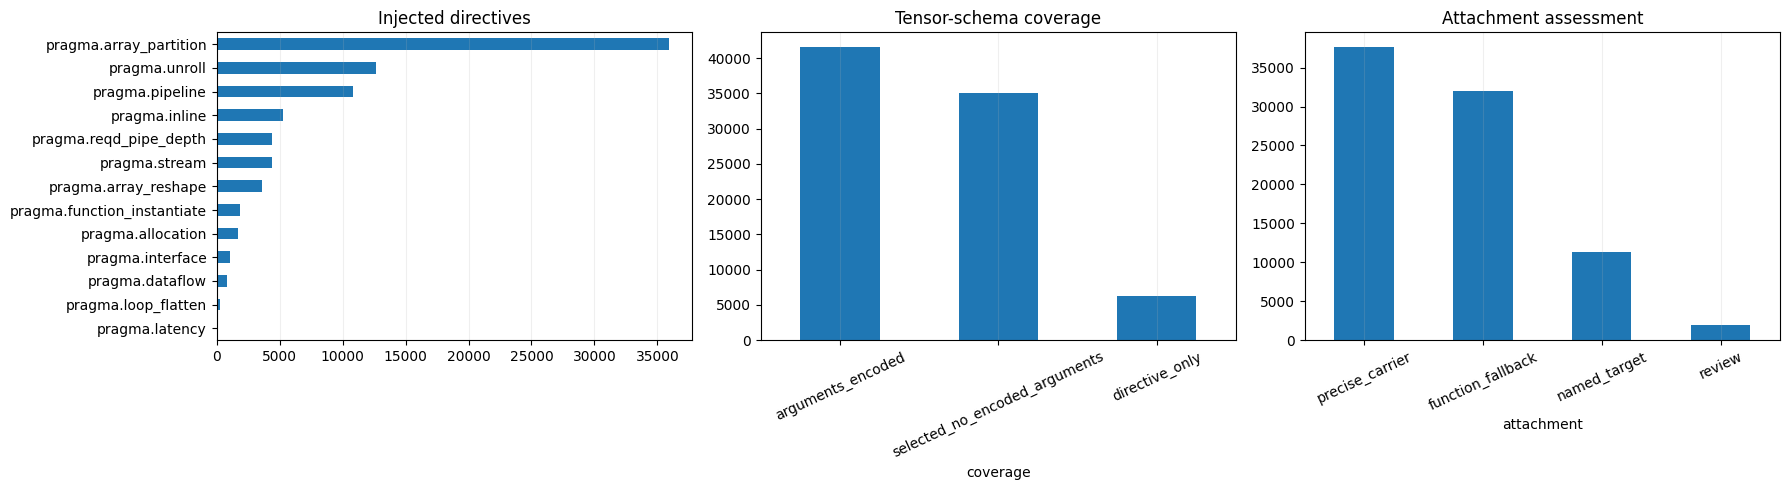

coverage,arguments_encoded,directive_only,selected_no_encoded_arguments
directive,,,
pragma.allocation,0,0,1674
pragma.array_partition,29254,0,6705
pragma.array_reshape,2764,0,870
pragma.dataflow,0,0,822
pragma.function_instantiate,0,1810,0
pragma.inline,2371,0,2928
pragma.interface,1056,0,0
pragma.latency,73,0,0
pragma.loop_flatten,0,0,226


anchor_reason,function_entry,llvm.sideeffect,llvm.sideeffect_fallback,named_target
directive,,,,
pragma.allocation,1674,0,0,0
pragma.array_partition,397,22970,6680,5912
pragma.array_reshape,0,2756,870,8
pragma.dataflow,822,0,0,0
pragma.function_instantiate,0,0,0,1810
pragma.inline,5299,0,0,0
pragma.interface,0,0,0,1056
pragma.latency,73,0,0,0
pragma.loop_flatten,226,0,0,0


In [8]:
if pragma_audit.empty:
    print('No injected pragma nodes found.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    pragma_audit['directive'].value_counts().sort_values().plot.barh(ax=axes[0], title='Injected directives')
    pragma_audit['coverage'].value_counts().plot.bar(ax=axes[1], title='Tensor-schema coverage', rot=25)
    pragma_audit['attachment'].value_counts().plot.bar(ax=axes[2], title='Attachment assessment', rot=25)
    for axis in axes:
        axis.set_ylabel('')
        axis.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

    display(pd.crosstab(pragma_audit['directive'], pragma_audit['coverage']))
    display(pd.crosstab(pragma_audit['directive'], pragma_audit['anchor_reason']))

## Argument coverage

`encoded` means the current tensorizer consumes the argument. `structural` means it is a target represented by pragma edges. `retained_only` means it survives in JSON and the pragma dump but currently contributes no learned feature.

In [9]:
argument_rows = []
for row in pragma_audit.itertuples(index=False):
    for status, values in (
        ('encoded', row.encoded_arguments),
        ('structural', row.structural_arguments),
        ('retained_only', row.retained_only_arguments),
    ):
        for token in values:
            key, _, value = token.partition('=')
            argument_rows.append({
                'directive': row.directive,
                'argument': key,
                'value': value,
                'status': status,
                'graph': row.graph,
            })
argument_audit = pd.DataFrame(argument_rows)

if argument_audit.empty:
    print('No pragma arguments found.')
else:
    argument_summary = (
        argument_audit.groupby(['directive', 'argument', 'status'])
        .size().rename('count').reset_index()
        .sort_values(['status', 'count'], ascending=[True, False])
    )
    display(argument_summary)
    print('Most common retained-only values:')
    display(
        argument_audit[argument_audit['status'] == 'retained_only']
        .groupby(['directive', 'argument', 'value']).size()
        .rename('count').sort_values(ascending=False).head(50).reset_index()
    )

,directive,argument,status,count
12,pragma.array_partition,complete,encoded,29254
13,pragma.array_partition,dim,encoded,10390
35,pragma.stream,depth,encoded,4378
18,pragma.array_reshape,block,encoded,2017
25,pragma.inline,recursive,encoded,1990
31,pragma.pipeline,ii,encoded,1687
33,pragma.pipeline,rewind,encoded,1614
19,pragma.array_reshape,complete,encoded,747
20,pragma.array_reshape,dim,encoded,747
26,pragma.interface,ap_vld,encoded,747


Most common retained-only values:


,directive,argument,value,count
0,pragma.array_partition,_carrier_arg_4,false,29650
1,pragma.array_partition,_carrier_arg_2,0,29650
2,pragma.array_partition,_carrier_arg_1,2,29650
3,pragma.array_partition,_carrier_arg_3,1,20670
4,pragma.array_partition,_carrier_arg_3,0,8663
5,pragma.array_reshape,_carrier_arg_3,1,2879
6,pragma.array_reshape,_carrier_arg_1,1,2879
7,pragma.reqd_pipe_depth,_carrier_arg_1,1,1872
8,pragma.array_reshape,_carrier_arg_2,1,1732
9,pragma.array_reshape,factor,block_factor,1585


## Unmatched compiler records and attachments

Unmatched records commonly come from pragmas in included template headers whose functions were not instantiated in the final CDFG. They are retained for audit but intentionally not injected as model nodes. Review unusually high unmatched counts and every `missing` or `review` attachment.

In [10]:
if unmatched_audit.empty:
    print('No unmatched compiler records.')
else:
    display(
        unmatched_audit.groupby(['directive', 'function']).size()
        .rename('count').sort_values(ascending=False).head(100).reset_index()
    )

review_columns = [
    'graph', 'pragma_id', 'directive', 'anchor_reason', 'attachment',
    'target_count', 'target_types', 'target_names', 'matched_target_names',
    'raw_options',
]
if pragma_audit.empty:
    print('No injected attachments to review.')
else:
    display(
        pragma_audit[pragma_audit['attachment'].isin(['missing', 'review'])][review_columns]
        .sort_values(['attachment', 'directive', 'graph'])
    )

,directive,function,count
0,inline,product,6336
1,unroll,softmax_stable,4284
2,unroll,dense_compressed,4224
3,unroll,conv_1d_latency_cl,3892
4,pipeline,repack_stream,3008
...,...,...,...
95,pipeline,global_pooling1d_cl,528
96,pipeline,global_pooling2d_cl,528
97,unroll,global_pooling2d_cl,528
98,unroll,global_pooling1d_cl,528


,graph,pragma_id,directive,anchor_reason,attachment,target_count,target_types,target_names,matched_target_names,raw_options
14,2layer/archive_1/0162624c-ca32-4e05-a8be-48c9d...,6778,pragma.array_partition,named_target,review,1,[instruction],tmpmult,[],variable=tmpmult complete
16,2layer/archive_1/0162624c-ca32-4e05-a8be-48c9d...,6780,pragma.array_partition,named_target,review,1,[instruction],mult,[],variable=mult complete
45,2layer/archive_1/01e4f100-40c0-4490-b7a6-ae37c...,6777,pragma.array_partition,named_target,review,1,[instruction],tmpmult,[],variable=tmpmult complete
47,2layer/archive_1/01e4f100-40c0-4490-b7a6-ae37c...,6779,pragma.array_partition,named_target,review,1,[instruction],mult,[],variable=mult complete
76,2layer/archive_1/0bc7e3b8-c2a6-427a-ab7b-97c8d...,6774,pragma.array_partition,named_target,review,1,[instruction],tmpmult,[],variable=tmpmult complete
...,...,...,...,...,...,...,...,...,...,...
82352,rule4ml/archive_1/eea79f2ee33e9eba8e086cce0a1f...,57861,pragma.array_partition,named_target,review,1,[instruction],tmpmult,[],variable=tmpmult complete
82354,rule4ml/archive_1/eea79f2ee33e9eba8e086cce0a1f...,57863,pragma.array_partition,named_target,review,1,[instruction],mult,[],variable=mult complete
82530,rule4ml/archive_1/f2f40f2151e0fd30f1f868836e50...,62031,pragma.array_partition,named_target,review,1,[instruction],data_array,[],variable=data_array complete
82566,rule4ml/archive_1/f2f40f2151e0fd30f1f868836e50...,62067,pragma.array_partition,named_target,review,1,[instruction],tmpmult,[],variable=tmpmult complete


## Interactive attachment inspector

Select a graph and pragma to inspect its complete injected feature dictionary, decoded learned features, direct attachment edges, target node text, and source-level target-name matches.

In [11]:
def decoded_tensor_features(node):
    vector = pragma_embedding(node)
    decoded = [{'feature': 'directive_id', 'value': int(vector[0])}]
    numeric_offset = 1
    mask_offset = 1 + len(PRAGMA_NUMERIC_ARGUMENTS)
    categorical_offset = 1 + 2 * len(PRAGMA_NUMERIC_ARGUMENTS)
    for index, key in enumerate(PRAGMA_NUMERIC_ARGUMENTS):
        if vector[mask_offset + index]:
            decoded.append({'feature': key, 'value': float(vector[numeric_offset + index])})
    for index, (key, value) in enumerate(PRAGMA_CATEGORICAL_ARGUMENTS):
        if vector[categorical_offset + index]:
            decoded.append({'feature': f'{key}={value}', 'value': 1.0})
    return pd.DataFrame(decoded)


def inspect_pragma(graph_name, pragma_id):
    path = GRAPH_ROOT / graph_name
    graph = json.loads(path.read_text())
    nodes = graph.get('nodes', [])
    node_by_id = {int(node['id']): node for node in nodes}
    pragma = node_by_id[int(pragma_id)]
    links = [
        link for link in graph.get('links', [])
        if int(link.get('flow', -1)) == FLOW_PRAGMA
        and int(link.get('source', -1)) == int(pragma_id)
    ]
    targets = [node_by_id[int(link['target'])] for link in links]
    assessment, matches = attachment_assessment(pragma, targets)

    print(f"{pragma.get('text')}  |  node {pragma_id}  |  {assessment}")
    display(pd.DataFrame([
        {'feature': key, 'value': value}
        for key, value in pragma.get('features', {}).items()
    ]))
    print('Learned tensor features:')
    display(decoded_tensor_features(pragma))

    target_rows = []
    expected_names = [name for name in str(feature_value(pragma, 'target_names', '')).split(',') if name]
    for target in targets:
        node_type = int(target.get('type', -1))
        text = full_text(target)
        target_rows.append({
            'id': int(target['id']),
            'type': NODE_TYPES[node_type] if 0 <= node_type < len(NODE_TYPES) else 'unknown',
            'text': target.get('text', ''),
            'full_text': text[:300],
            'matched_target_names': [name for name in expected_names if f'%{name}' in text],
        })
    display(pd.DataFrame(target_rows))

    figure, axis = plt.subplots(figsize=(12, max(3, 1.1 * len(targets))))
    graph_view = nx.DiGraph()
    graph_view.add_node(int(pragma_id), label=pragma.get('text', ''), kind='pragma')
    for target in targets:
        node_type = int(target.get('type', -1))
        kind = NODE_TYPES[node_type] if 0 <= node_type < len(NODE_TYPES) else 'unknown'
        graph_view.add_node(int(target['id']), label=f"{kind} {target['id']}: {target.get('text', '')[:45]}", kind=kind)
        graph_view.add_edge(int(pragma_id), int(target['id']))
    positions = {int(pragma_id): (0, 0)}
    for index, target in enumerate(targets):
        positions[int(target['id'])] = (1, (len(targets) - 1) / 2 - index)
    color_map = {'pragma': '#d95f02', 'instruction': '#1b9e77', 'variable': '#7570b3', 'constant': '#666666'}
    colors = [color_map.get(graph_view.nodes[node]['kind'], '#666666') for node in graph_view.nodes]
    labels = {node: graph_view.nodes[node]['label'] for node in graph_view.nodes}
    nx.draw_networkx(graph_view, positions, labels=labels, node_color=colors, node_size=1800, font_size=8, arrows=True, ax=axis)
    axis.set_title(f'Attachment edges; expected names={expected_names}, matched={sorted(matches)}')
    axis.axis('off')
    plt.tight_layout()
    plt.show()


if pragma_audit.empty:
    print('No pragmas available to inspect.')
elif widgets is None:
    first = pragma_audit.iloc[0]
    inspect_pragma(first['graph'], int(first['pragma_id']))
else:
    graph_dropdown = widgets.Dropdown(
        options=sorted(pragma_audit['graph'].unique()),
        description='Graph:',
        layout=widgets.Layout(width='95%'),
    )
    pragma_dropdown = widgets.Dropdown(description='Pragma:')
    output = widgets.Output()

    def update_pragmas(*_):
        rows = pragma_audit[pragma_audit['graph'] == graph_dropdown.value]
        pragma_dropdown.options = [
            (f"{row.directive} | node {row.pragma_id} | {row.attachment}", int(row.pragma_id))
            for row in rows.itertuples(index=False)
        ]

    def update_output(*_):
        if pragma_dropdown.value is None:
            return
        with output:
            clear_output(wait=True)
            inspect_pragma(graph_dropdown.value, pragma_dropdown.value)

    graph_dropdown.observe(update_pragmas, names='value')
    pragma_dropdown.observe(update_output, names='value')
    update_pragmas()
    update_output()
    display(widgets.VBox([graph_dropdown, pragma_dropdown, output]))